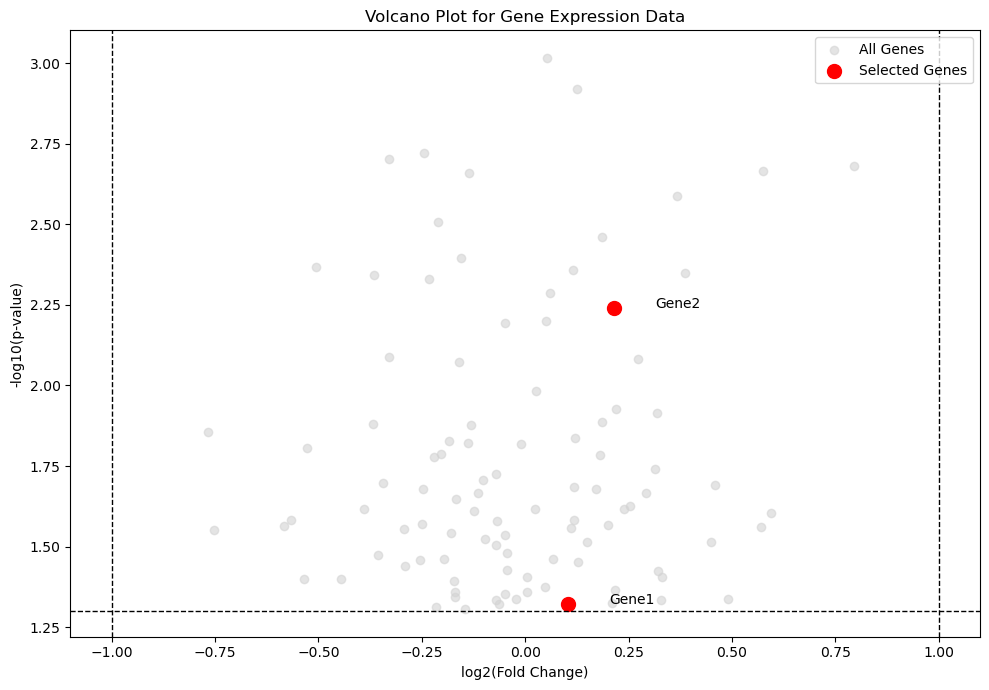

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv("cancer_expression.csv")

# Identify control and treatment columns
control_cols = [col for col in df.columns if col.startswith("Control")]
treatment_cols = [col for col in df.columns if col.startswith("Treatment")]

# Calculate log2 fold change for each gene
df["log2FoldChange"] = np.log2(df[treatment_cols].mean(axis=1) / df[control_cols].mean(axis=1))

# Simulate p-values (or you can replace with real ones later)
df["pvalue"] = np.random.uniform(0.0001, 0.05, len(df))
df["neg_log10_pvalue"] = -np.log10(df["pvalue"])

# Thresholds
log2fc_threshold = 1
pvalue_threshold = 0.05

# Highlighted genes (you can change names based on your file)
highlight_genes = ["Gene1", "Gene2"]

# Create the volcano plot
plt.figure(figsize=(10, 7))

# Plot all genes in gray
plt.scatter(df["log2FoldChange"], df["neg_log10_pvalue"], color="lightgray", alpha=0.6, label="All Genes")

# Highlight specific genes
highlight_df = df[df["Gene"].isin(highlight_genes)]
plt.scatter(highlight_df["log2FoldChange"], highlight_df["neg_log10_pvalue"], color="red", s=100, label="Selected Genes")

# Add text labels for the selected genes
for _, row in highlight_df.iterrows():
    plt.text(row["log2FoldChange"] + 0.1, row["neg_log10_pvalue"], row["Gene"], fontsize=10, color="black")

# Add threshold lines
plt.axvline(x=log2fc_threshold, color="black", linestyle="--", linewidth=1)
plt.axvline(x=-log2fc_threshold, color="black", linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(pvalue_threshold), color="black", linestyle="--", linewidth=1)

# Labels and title
plt.xlabel("log2(Fold Change)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot for Gene Expression Data")
plt.legend()
plt.tight_layout()


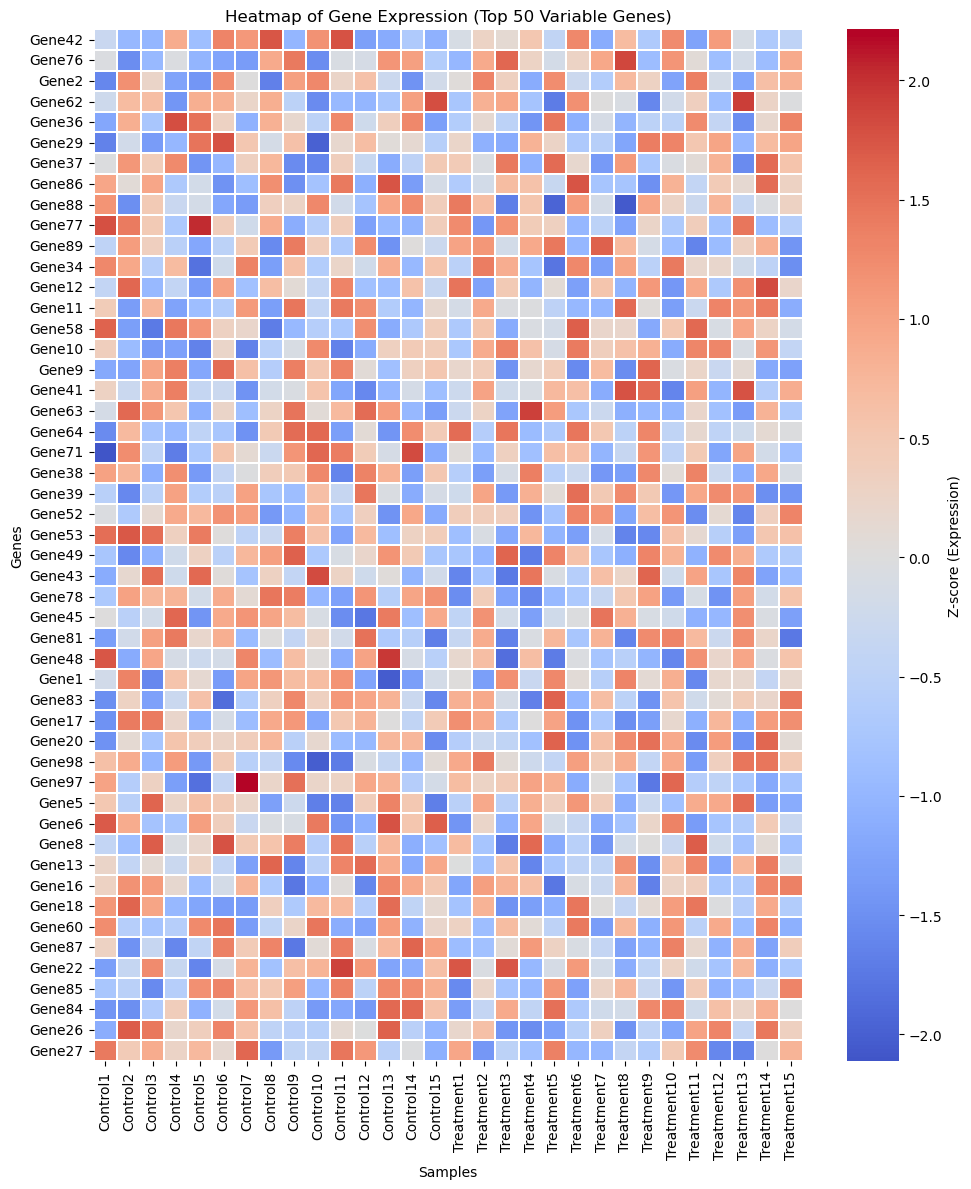

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read dataset
df = pd.read_csv("cancer_expression.csv")

# Identify control and treatment columns
control_cols = [col for col in df.columns if col.startswith("Control")]
treatment_cols = [col for col in df.columns if col.startswith("Treatment")]

# Ensure the "Gene" column exists
if "Gene" not in df.columns:
    raise ValueError("Your dataset must contain a 'Gene' column with gene names.")

# Set Gene column as index
df.set_index("Gene", inplace=True)

# Combine only expression columns
expr_df = df[control_cols + treatment_cols]

# Optionally, normalize (z-score per gene)
expr_df_zscore = expr_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# Optional: choose top variable genes to avoid overcrowding (e.g., top 50)
top_var_genes = expr_df_zscore.var(axis=1).sort_values(ascending=False).head(50).index
expr_df_zscore = expr_df_zscore.loc[top_var_genes]

# Create heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(
    expr_df_zscore,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Z-score (Expression)"},
    linewidths=0.3,
)

# Add titles and labels
plt.title("Heatmap of Gene Expression (Top 50 Variable Genes)")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()
plt.show()


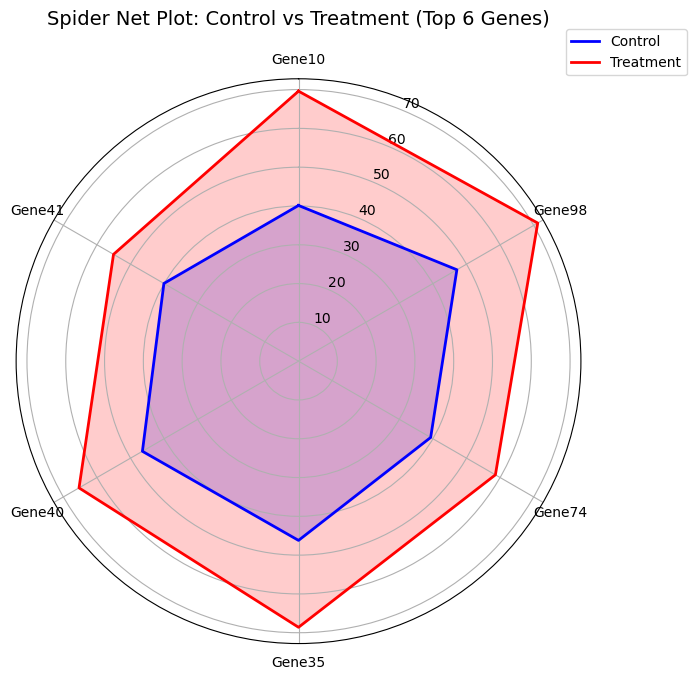

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Read dataset ---
df = pd.read_csv("cancer_expression.csv")

# Identify control and treatment columns
control_cols = [col for col in df.columns if col.startswith("Control")]
treatment_cols = [col for col in df.columns if col.startswith("Treatment")]

# Ensure "Gene" column exists
if "Gene" not in df.columns:
    raise ValueError("Dataset must contain a 'Gene' column.")

# Calculate mean expression for each group
df["Control_mean"] = df[control_cols].mean(axis=1)
df["Treatment_mean"] = df[treatment_cols].mean(axis=1)

# --- Select top genes (e.g., based on fold change) ---
df["log2FoldChange"] = np.log2((df["Treatment_mean"] + 1e-9) / (df["Control_mean"] + 1e-9))
top_genes = df.nlargest(6, "log2FoldChange")  # Top 6 upregulated genes

# Data for plotting
categories = top_genes["Gene"].values
control_values = top_genes["Control_mean"].values
treatment_values = top_genes["Treatment_mean"].values

# Close the plot loop (repeat first value at the end)
control_values = np.append(control_values, control_values[0])
treatment_values = np.append(treatment_values, treatment_values[0])

# Angle setup for each axis
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# --- Create radar plot ---
plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# Draw one axis per variable + add labels
plt.xticks(angles[:-1], categories, color="black", size=10)

# Plot Control
ax.plot(angles, control_values, linewidth=2, linestyle='solid', label='Control', color='blue')
ax.fill(angles, control_values, 'b', alpha=0.2)

# Plot Treatment
ax.plot(angles, treatment_values, linewidth=2, linestyle='solid', label='Treatment', color='red')
ax.fill(angles, treatment_values, 'r', alpha=0.2)

# Add labels
plt.title("Spider Net Plot: Control vs Treatment (Top 6 Genes)", size=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

# Improve appearance
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.tight_layout()

plt.show()



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

# --- Load dataset ---
df = pd.read_csv("cancer_expression.csv")

# Identify control and treatment columns
control_cols = [col for col in df.columns if col.startswith("Control")]
treatment_cols = [col for col in df.columns if col.startswith("Treatment")]

# Ensure 'Gene' column exists
if "Gene" not in df.columns:
    raise ValueError("Dataset must contain a 'Gene' column.")

# --- Compute differential expression ---
df["log2FoldChange"] = np.log2((df[treatment_cols].mean(axis=1) + 1e-9) / 
                               (df[control_cols].mean(axis=1) + 1e-9))
df["pvalue"] = np.random.uniform(0.0001, 0.05, len(df))  # simulated p-values
df["significant"] = (abs(df["log2FoldChange"]) > 1) & (df["pvalue"] < 0.05)

# --- Simulate multiple conditions for demonstration ---
# (In real data, replace these with actual comparisons)
np.random.seed(42)
df["Set_A"] = df["significant"] & (np.random.rand(len(df)) > 0.5)
df["Set_B"] = df["significant"] & (np.random.rand(len(df)) > 0.5)
df["Set_C"] = df["significant"] & (np.random.rand(len(df)) > 0.5)

# --- Prepare data for UpSet plot ---
# Identify which sets each gene belongs to
gene_sets = []
for _, row in df.iterrows():
    membership = []
    if row["Set_A"]:
        membership.append("Set_A")
    if row["Set_B"]:
        membership.append("Set_B")
    if row["Set_C"]:
        membership.append("Set_C")
    if membership:
        gene_sets.append(membership)

# Create UpSet data structure
upset_data = from_memberships(gene_sets)

# --- Create UpSet plot ---
plt.figure(figsize=(10, 6))
upset = UpSet(upset_data, show_counts=True, sort_by='degree', sort_categories_by='input')
upset.plot()
plt.suptitle("UpSet Plot: Overlap of Significant Genes Across Conditions", y=1.02)
plt.show()


ModuleNotFoundError: No module named 'upsetplot'

C:\Users\2020asp65\AppData\Local\Temp\ipykernel_4372\514710279.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


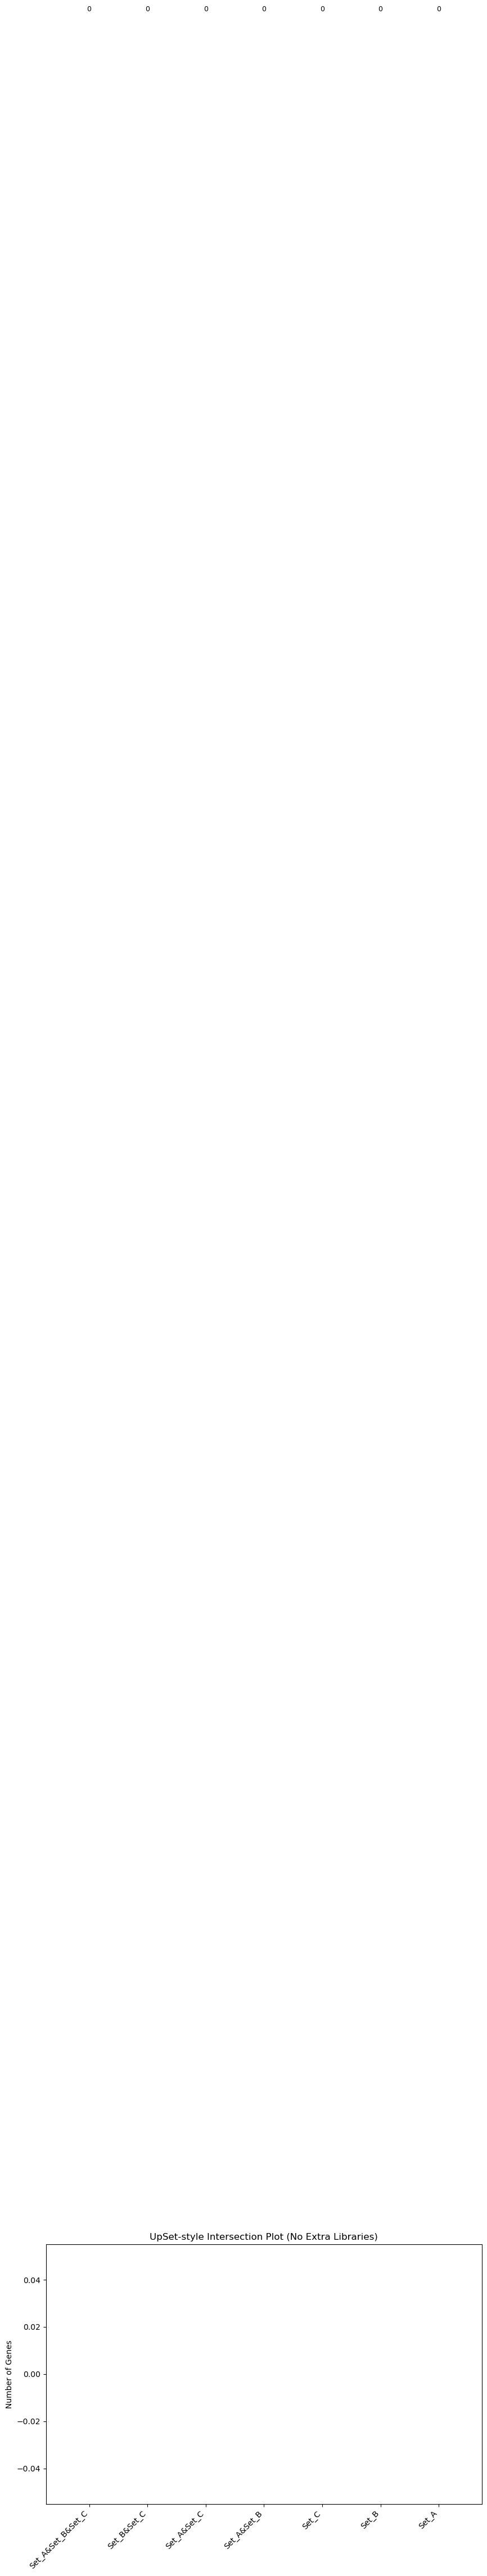

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import chain, combinations

# --- Load dataset ---
df = pd.read_csv("cancer_expression.csv")

# Identify control and treatment columns
control_cols = [col for col in df.columns if col.startswith("Control")]
treatment_cols = [col for col in df.columns if col.startswith("Treatment")]

# Ensure "Gene" column exists
if "Gene" not in df.columns:
    raise ValueError("Dataset must contain a 'Gene' column.")

# --- Compute differential expression ---
df["log2FoldChange"] = np.log2((df[treatment_cols].mean(axis=1) + 1e-9) / 
                               (df[control_cols].mean(axis=1) + 1e-9))
df["pvalue"] = np.random.uniform(0.0001, 0.05, len(df))
df["significant"] = (abs(df["log2FoldChange"]) > 1) & (df["pvalue"] < 0.05)

# --- Simulate multiple experimental sets ---
np.random.seed(42)
df["Set_A"] = df["significant"] & (np.random.rand(len(df)) > 0.5)
df["Set_B"] = df["significant"] & (np.random.rand(len(df)) > 0.5)
df["Set_C"] = df["significant"] & (np.random.rand(len(df)) > 0.5)

# --- Build combinations of intersections ---
sets = ["Set_A", "Set_B", "Set_C"]
combos = list(chain.from_iterable(combinations(sets, r) for r in range(1, len(sets)+1)))

counts = []
labels = []

for combo in combos:
    mask = np.logical_and.reduce([df[s] for s in combo])
    count = mask.sum()
    counts.append(count)
    labels.append("&".join(combo))

# --- Sort intersections by count ---
counts = np.array(counts)
labels = np.array(labels)
sort_idx = np.argsort(counts)[::-1]
counts = counts[sort_idx]
labels = labels[sort_idx]

# --- Plot ---
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(counts)), counts, color="steelblue")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.ylabel("Number of Genes")
plt.title("UpSet-style Intersection Plot (No Extra Libraries)")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{int(height)}", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



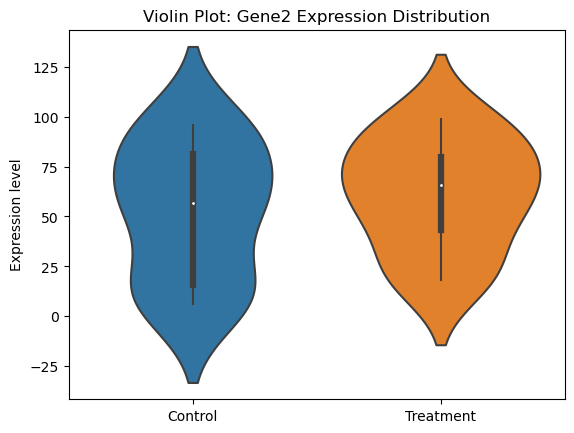

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Read dataset ---
df = pd.read_csv("cancer_expression.csv")

# Identify control and treatment columns
gene = "Gene2"
gene_row = df[df["Gene"] == gene].iloc[0]

data=[gene_row[control_cols].values,gene_row[treatment_cols].values]

sns.violinplot(data=data)
plt.xticks([0,1],["Control","Treatment"])
plt.title(f"Violin Plot: {gene} Expression Distribution")

plt.ylabel("Expression level")
plt.show()
